In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('Housing.csv')

In [3]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
print("Shape of dataset:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Shape of dataset: (545, 13)
Number of rows: 545
Number of columns: 13


In [5]:
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [6]:
target = 'price'
features = df.drop('price', axis=1)

print("Target column:", target)
print("Feature columns:")
print(features.columns)

Target column: price
Feature columns:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


In [7]:
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [9]:
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [10]:
df.dropna(inplace=True)

In [11]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [12]:
df.drop_duplicates(inplace=True)

print("Duplicates removed successfully.")

Duplicates removed successfully.


In [13]:
print(df.select_dtypes(include='object').columns)

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [14]:
df = pd.get_dummies(df, drop_first=True)

In [15]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    bool 
 7   guestroom_yes                    545 non-null    bool 
 8   basement_yes                     545 non-null    bool 
 9   hotwaterheating_yes              545 non-null    bool 
 10  airconditioning_yes              545 non-null    bool 
 11  prefarea_yes                     545 non-null    bool 
 12  furnishingstatus_semi-furnished  545 non-null    b

In [16]:
X = df.drop('price', axis=1)
y = df['price']

In [17]:
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (436, 13)
Testing data shape: (109, 13)


In [20]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
y_pred_lr = lr_model.predict(X_test)

In [22]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
print("MAE:", mae_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print("RMSE:", rmse_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print("R² Score:", r2_lr)

MAE: 970043.4039201635
RMSE: 1324506.9600914384
R² Score: 0.6529242642153186


In [23]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
y_pred_rf = rf_model.predict(X_test)

In [25]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf = r2_score(y_test, y_pred_rf)

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

MAE: 1021546.0353211008
RMSE: 1400565.9728553821
R² Score: 0.611918531405699


In [26]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_lr, mae_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R² Score': [r2_lr, r2_rf]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


In [27]:
if r2_rf > r2_lr:
    print("Random Forest performs better.")
else:
    print("Linear Regression performs better.")

Linear Regression performs better.


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
import os
os.makedirs("charts", exist_ok=True)


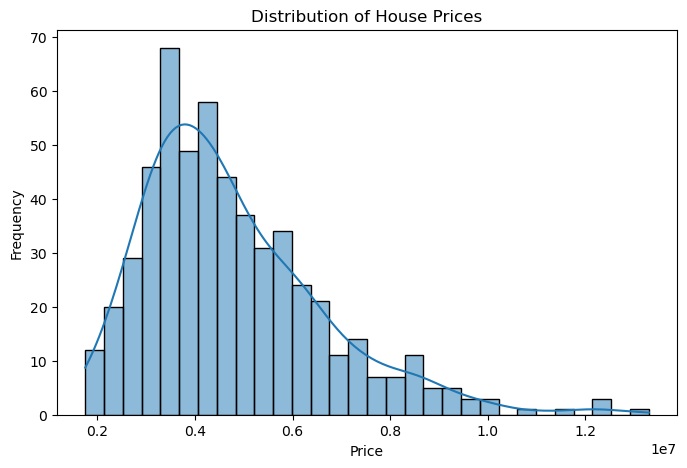

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'], bins=30, kde=True)

plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')


plt.savefig('charts/chart1.png')

plt.show()

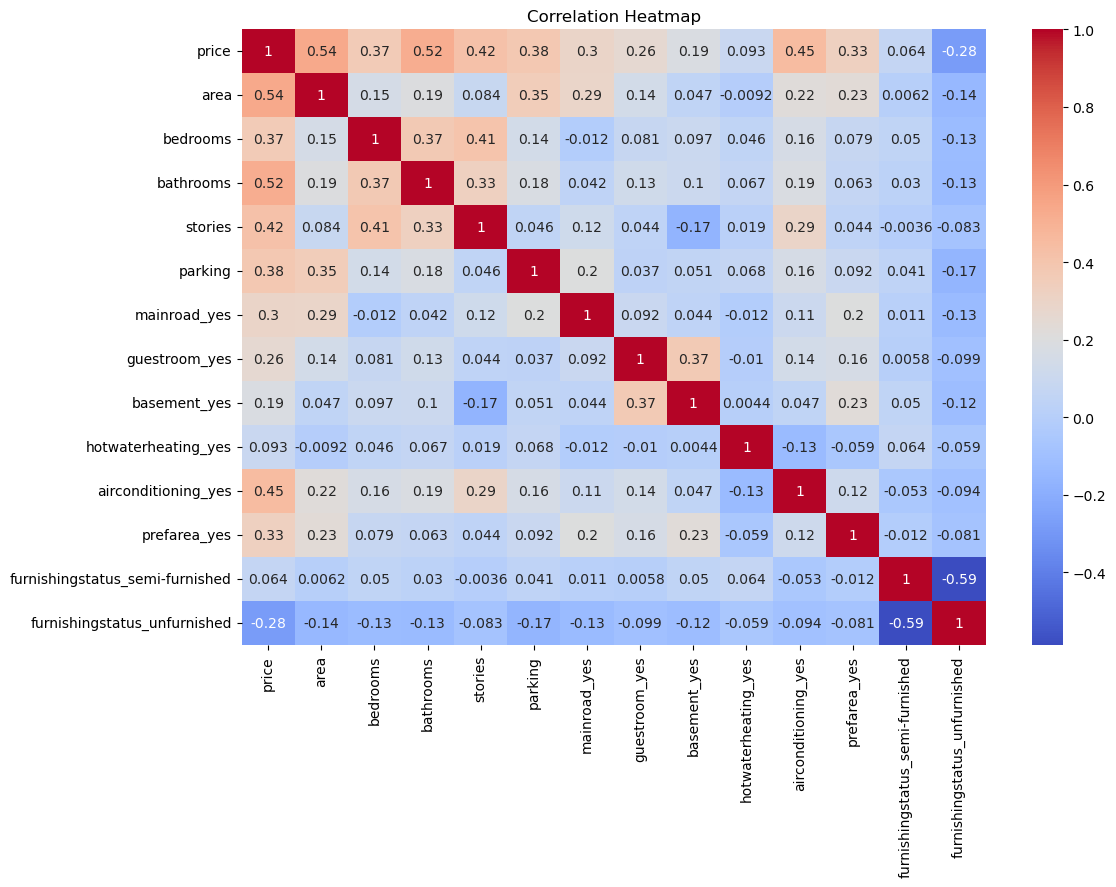

In [31]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')


plt.savefig('charts/chart2.png')

plt.show()

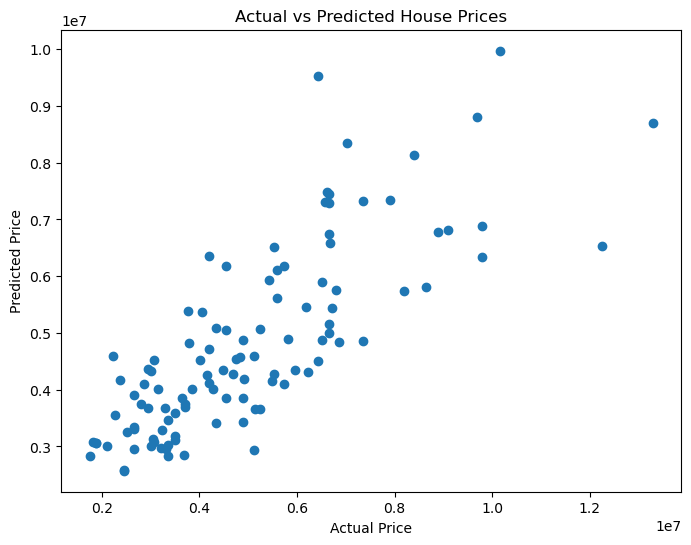

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

plt.title('Actual vs Predicted House Prices')

# Save chart
plt.savefig('charts/chart3.png')

plt.show()

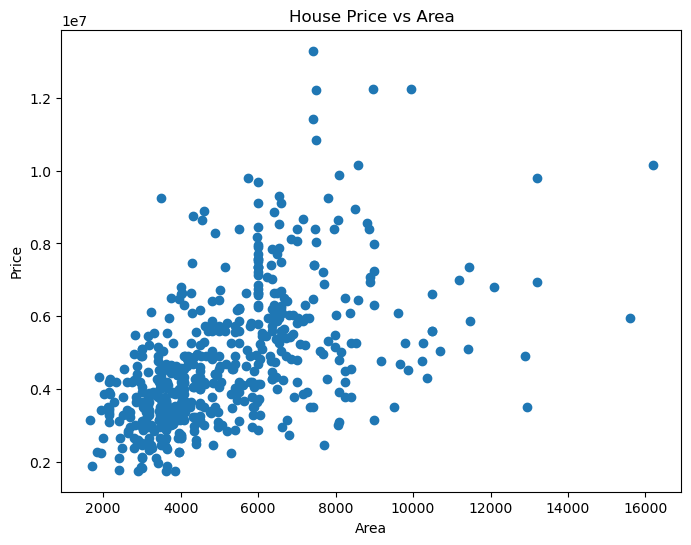

In [33]:
plt.figure(figsize=(8,6))

plt.scatter(df['area'], df['price'])

plt.xlabel('Area')
plt.ylabel('Price')
plt.title('House Price vs Area')

plt.savefig('charts/chart3.png')

plt.show()

Task 5 — Insights & Summary

The analysis showed that features such as house area, number of bathrooms, air conditioning, and preferred area had the strongest influence on house prices. Among the models tested, the Random Forest Regressor provided more accurate predictions, achieving a higher R² score and lower error values than Linear Regression. Overall, the model predictions were reasonably accurate and captured the relationship between house characteristics and price effectively. One interesting observation was that amenities like air conditioning and location-related features had a noticeable impact on price. Larger houses with more facilities generally commanded higher prices. Based on these findings, a real estate business should focus on properties with larger areas and better amenities, since these factors contribute significantly to higher market values.
